# ORB (Oriented FAST and Rotated BRIEF)

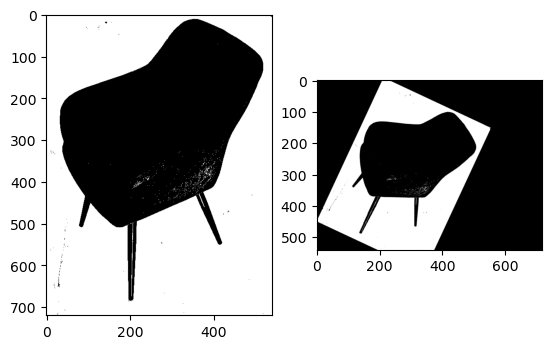

In [5]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path = './chair.jpg'

img = cv.imread(path)
img = cv.resize(img, None, fx = 0.3, fy = 0.3)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
val, img_bin = cv.threshold(img_gray, 130, 255, cv.THRESH_BINARY)

# prepare rotation
height = img_bin.shape[0] 
width = img_bin.shape[1]
center = (int(height / 2) , int(width / 2))
scale = 0.7

# rotate and scale image
M = cv.getRotationMatrix2D(center, -25, scale)
rotated = cv.warpAffine(img_bin, M, img_bin.shape)


plt.figure()
plt.subplot(121)
plt.imshow(img_bin, cmap = 'gray')
plt.subplot(122)
plt.imshow(rotated, cmap = 'gray')

plt.show()

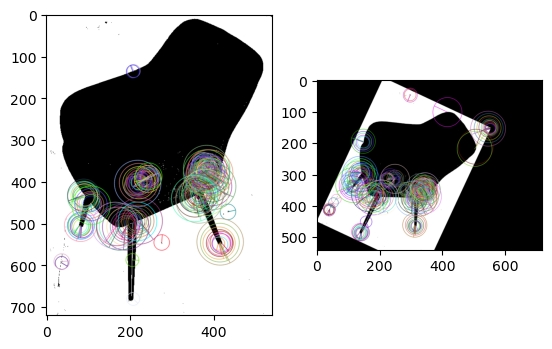

In [6]:
# create, detect, compute keypoints and its desprictors, then display result

max_features = 200
orb = cv.ORB_create(max_features)
keypoints1, descriptors1 = orb.detectAndCompute(img_bin, None)
keypoints2, descriptors2 = orb.detectAndCompute(rotated, None)

gray_kp = cv.drawKeypoints(img_bin, keypoints1, None, flags = cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
rotated_kp = cv.drawKeypoints(rotated, keypoints2, None, flags = cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure()
plt.subplot(121)
plt.imshow(gray_kp)
plt.subplot(122)
plt.imshow(rotated_kp)

plt.show()


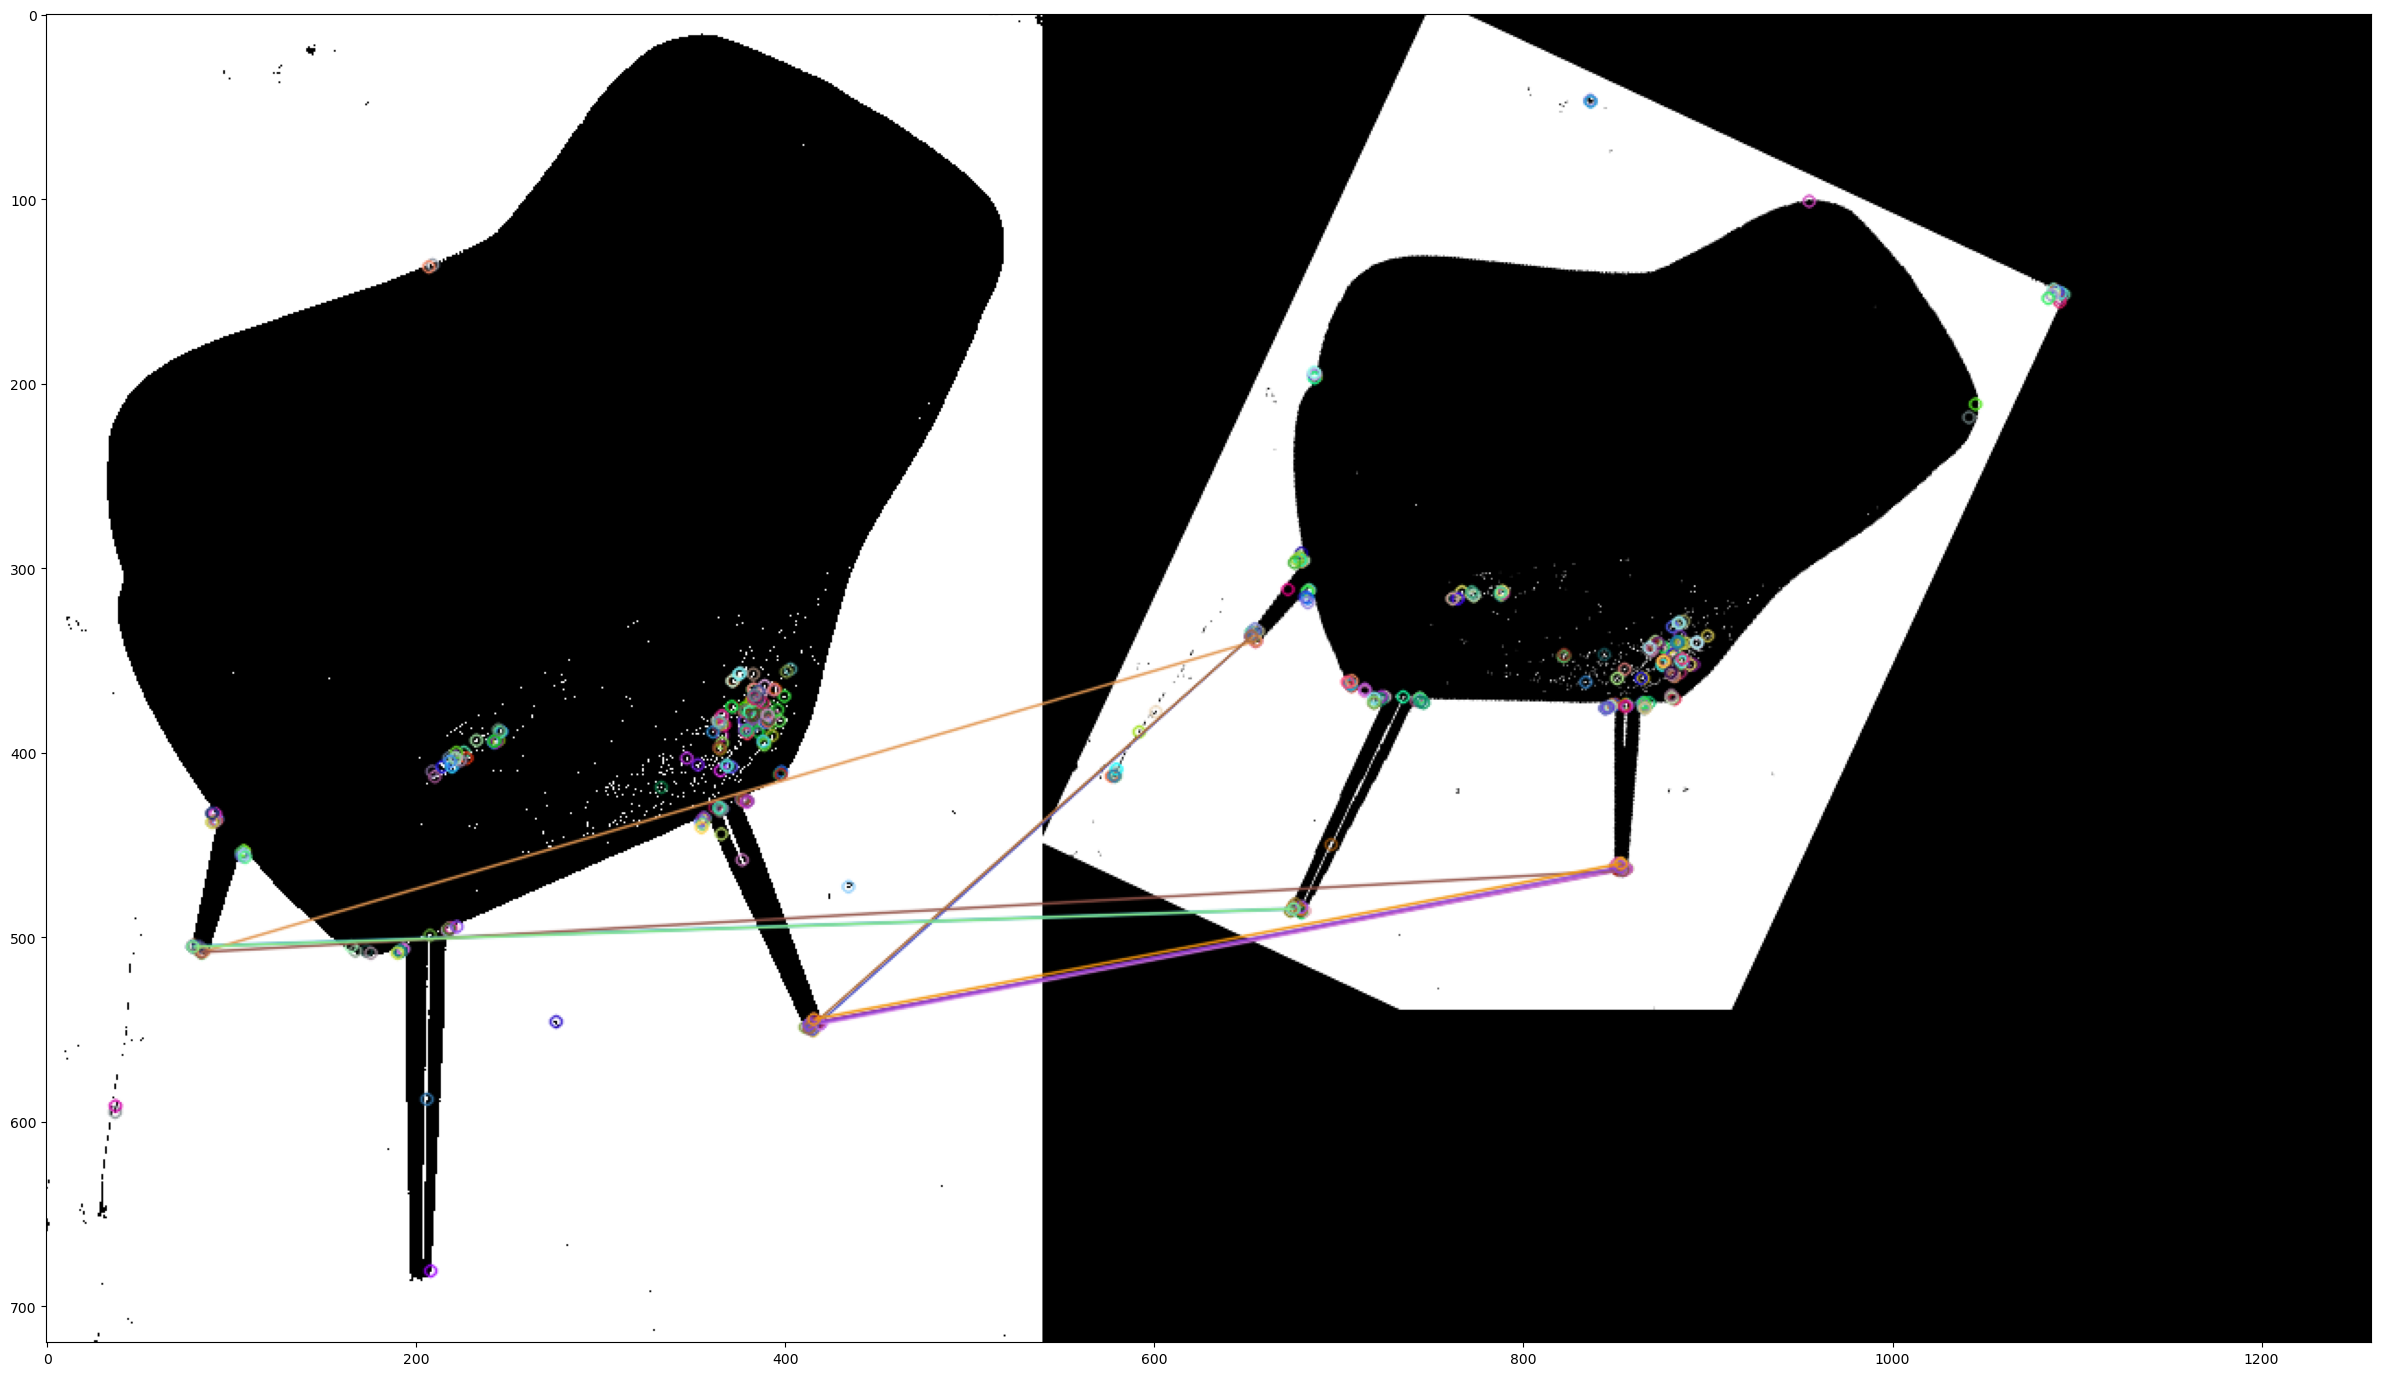

In [8]:
# match keypoints
kp_matcher = cv.DescriptorMatcher_create(cv.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)

# create list
kp_matches = list(kp_matcher.match(descriptors1, descriptors2, None))

kp_matches.sort(key=lambda x: x.distance, reverse=False)

numGoodMatches = int(len(kp_matches) * 0.05)            # use the top 5% of the matches as good matches
matches = kp_matches[:numGoodMatches]

# draw the top 5% matches
image = cv.drawMatches(img_bin, keypoints1, rotated, keypoints2, matches, None)

plt.figure(figsize=(30, 30))
plt.imshow(image)
plt.show()